In [1]:
!wget -O Xrays5.zip "https://www.dropbox.com/scl/fi/2e2nz1oyxbzil4jc2ch9h/Xrays5.zip?rlkey=5qquhnpcmyzeyprrf3szdg897&dl=1"

!unzip Xrays5.zip -d Xrays5

--2025-11-25 22:53:12--  https://www.dropbox.com/scl/fi/2e2nz1oyxbzil4jc2ch9h/Xrays5.zip?rlkey=5qquhnpcmyzeyprrf3szdg897&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucc50b7a88ef01628ff723b6df95.dl.dropboxusercontent.com/cd/0/inline/C10upMhjLC6L312V8dycifo6xctqDsdOnDaC13JSDnHyNh7cilHJ85B3yf-qFKo8g8bHvxr_I11bx2lEja_5u-lr_YqGXndYPyP8nBvuaGFAgd9zFxxdnmZ_O1-OsSGKJ7k/file?dl=1# [following]
--2025-11-25 22:53:12--  https://ucc50b7a88ef01628ff723b6df95.dl.dropboxusercontent.com/cd/0/inline/C10upMhjLC6L312V8dycifo6xctqDsdOnDaC13JSDnHyNh7cilHJ85B3yf-qFKo8g8bHvxr_I11bx2lEja_5u-lr_YqGXndYPyP8nBvuaGFAgd9zFxxdnmZ_O1-OsSGKJ7k/file?dl=1
Resolving ucc50b7a88ef01628ff723b6df95.dl.dropboxusercontent.com (ucc50b7a88ef01628ff723b6df95.dl.dropboxusercontent.com)... 162.125.3.15, 2620:100:601d:15::a27d:50f
Connecti

In [2]:
!wget -O Msegm5.zip "https://www.dropbox.com/scl/fi/khsadfjla2zahrne5b0mj/Seg5.zip?e=1&rlkey=uly4jv6799yci4qos4oz2zstj"

!unzip Msegm5.zip -d Msegm5

--2025-11-25 22:55:18--  https://www.dropbox.com/scl/fi/khsadfjla2zahrne5b0mj/Seg5.zip?e=1&rlkey=uly4jv6799yci4qos4oz2zstj
Resolving www.dropbox.com (www.dropbox.com)... 162.125.64.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.64.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucdff4abbc12f50e07713eac224e.dl.dropboxusercontent.com/cd/0/inline/C10qBlTlIBriuSnRBAasC4FVHIVeNUTkZNZutRAsJ-7uWr_Jp0E07Kn4ITJxYfgfp8wpf-Sm1aj6MuPU7oTtVS6g1epjDozdZsbKqOT5rWTQZFGOwCkURQZSqbgW_-rgm-g/file# [following]
--2025-11-25 22:55:19--  https://ucdff4abbc12f50e07713eac224e.dl.dropboxusercontent.com/cd/0/inline/C10qBlTlIBriuSnRBAasC4FVHIVeNUTkZNZutRAsJ-7uWr_Jp0E07Kn4ITJxYfgfp8wpf-Sm1aj6MuPU7oTtVS6g1epjDozdZsbKqOT5rWTQZFGOwCkURQZSqbgW_-rgm-g/file
Resolving ucdff4abbc12f50e07713eac224e.dl.dropboxusercontent.com (ucdff4abbc12f50e07713eac224e.dl.dropboxusercontent.com)... 162.125.3.15, 2620:100:601b:15::a27d:80f
Connecting to ucdff

In [2]:
import cv2
# cargar 5 radiografías
X1 = cv2.imread("Xrays5/X0001.png", cv2.IMREAD_GRAYSCALE)
X2 = cv2.imread("Xrays5/X0002.png", cv2.IMREAD_GRAYSCALE)
X3 = cv2.imread("Xrays5/X0003.png", cv2.IMREAD_GRAYSCALE)
X4 = cv2.imread("Xrays5/X0004.png", cv2.IMREAD_GRAYSCALE)
X5 = cv2.imread("Xrays5/X0005.png", cv2.IMREAD_GRAYSCALE)

# cargar las 5 segmentaciones manuales
M1 = cv2.imread("Msegm5/Y0001.png", cv2.IMREAD_GRAYSCALE)
M2 = cv2.imread("Msegm5/Y0002.png", cv2.IMREAD_GRAYSCALE)
M3 = cv2.imread("Msegm5/Y0003.png", cv2.IMREAD_GRAYSCALE)
M4 = cv2.imread("Msegm5/Y0004.png", cv2.IMREAD_GRAYSCALE)
M5 = cv2.imread("Msegm5/Y0005.png", cv2.IMREAD_GRAYSCALE)

In [3]:
import numpy as np

def error_promedio(S, M):
    # Asegurar que ambas imágenes tienen el mismo tamaño
    assert S.shape == M.shape, "Las imágenes deben tener el mismo tamaño"

    # Convertir a float por si vienen en uint8
    S = S.astype(float)
    M = M.astype(float)

    # Calcular error promedio
    E = np.mean(np.abs(S - M))

    return E

Usé el mismo algoritmo para segmentar las cinco imágenes, con algunas modificaciones al visualizar los resultados por separado y fui ajustando los parámetros de suavizado y los umbrales de segmentación, ya que algunas imágenes tenían zonas más claras que dificultaban la correcta segmentación de los pulmones. Además, en algunas imagenes cuando el suavizado era demasiado fuerte, los bordes llegaban a perderse porque eran menos oscuros que en otras imágenes, por lo que en esos casos fue necesario aplicar un suavizado menor.

## 1) "Segmentacion1": Usando algoritmos vistos en clase.

# Segmentacion Imagen 1

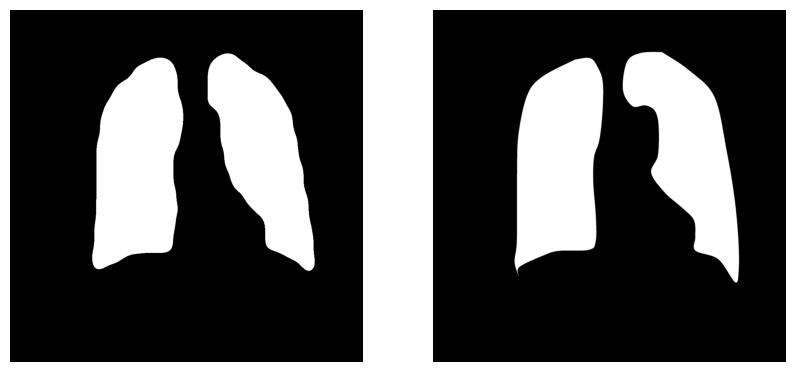

In [5]:
import cv2
import numpy as np
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage import morphology
import matplotlib.pyplot as plt

# Corrección morfológica inicial:
# Se usa una apertura gigante para estimar la iluminación general de la imagen.
# Esto deja solo el “fondo suave” y elimina zonas oscuras grandes como clavículas y costillas.
# Así obtenemos una especie de mapa de luz de la radiografía.
n = 280
Xe = cv2.morphologyEx(
    X1,
    cv2.MORPH_OPEN,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n))
)

# Restamos la iluminación estimada.
# Como los pulmones son claros, esta resta hace que lo oscuro (huesos) se destaque
# y que los pulmones sobresalgan más adelante.
Xd = X1.astype(float) - Xe.astype(float)

# Recorte de valores para mantener la imagen en un rango válido.
Xd_clipped = np.clip(Xd, 0, 255)
Xd_uint8 = Xd_clipped.astype('uint8')

# Suavizado de ruido:
# Un median blur ayuda a emparejar detalles pequeños y ruido.
# Esto hace que el umbral funcione mejor y no detecte basura.
Y0 = cv2.medianBlur(Xd_uint8, 3)

# Umbral inicial:
# Como los pulmones son claros y el proceso anterior destaca lo oscuro,
# este umbral separa más claramente pulmones (claros) del resto.
th = 35
D = Y0 > th

# Quitar regiones pequeñas
# Quitamos pequeños parches que no son pulmones.
S = morphology.remove_small_objects(D, min_size=10000, connectivity=2)

# Quitar regiones pegadas al borde
# Cualquier cosa que toque el borde suele ser caja torácica, clavículas o artefactos.
clean = clear_border(S)

# Cierre morfológico grande:
# Rellena huecos dentro de la zona pulmonar y une partes que quedaron separadas.
kernel = np.ones((70, 70), np.uint8)
lungs_uint8 = (clean.astype('uint8')) * 255
closing = cv2.morphologyEx(lungs_uint8, cv2.MORPH_CLOSE, kernel)

# Suavizado y rectificación de bordes:

# Apertura suave para eliminar “dientes” o bordes irregulares.
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
smooth = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel1)

# Cierre más fuerte para estirar y redondear mejor los bordes de los pulmones.
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (65, 65))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel2)

# Cierre vertical para corregir huecos o líneas producidas por costillas.
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel_vertical)

# Suavizado gaussiano para dejar bordes más limpios y redondeados.
smooth = cv2.GaussianBlur(smooth, (81, 81), 0)

# Re-umbralizar para recuperar una máscara binaria clara y limpia.
_, final_round_1 = cv2.threshold(smooth, 127, 255, cv2.THRESH_BINARY)

# Visualización
plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(final_round_1, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(M1, cmap="gray")
plt.axis("off")

plt.show()


In [6]:
final_round_1 = (final_round_1 > 127).astype(float)
M1 = (M1 > 127).astype(float)

E1 = error_promedio(final_round_1, M1)
print("Error promedio =", E1)

Error promedio = 0.035008


# Segmentacion Imagen 2

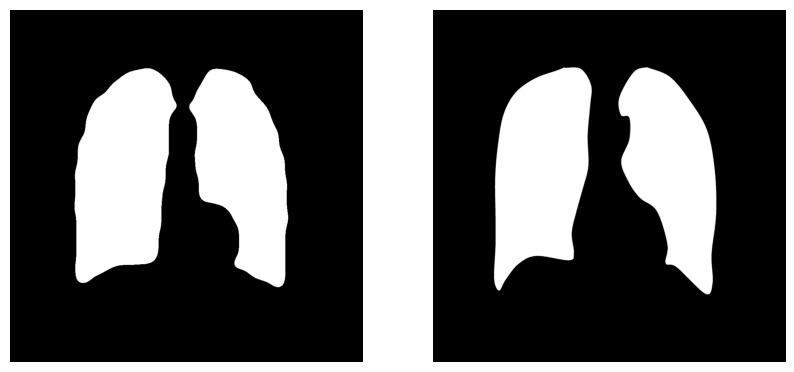

In [7]:
import cv2
import numpy as np
from skimage.segmentation import clear_border
from skimage import morphology
import matplotlib.pyplot as plt

# Estimar iluminación general
n = 280
Xe = cv2.morphologyEx(
    X2,
    cv2.MORPH_OPEN,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n))
)

# Corregir iluminación
Xd = X2.astype(float) - Xe.astype(float)
Xd_uint8 = np.clip(Xd, 0, 255).astype('uint8')

# Suavizado básico
Y0 = cv2.medianBlur(Xd_uint8, 3)

# Umbral inicial
th = 35
D = Y0 > th

# Quitar objetos pequeños
S = morphology.remove_small_objects(D, min_size=10000, connectivity=2)

# Quitar objetos en los bordes
clean = clear_border(S)

# Cierre grande para unir pulmones
kernel = np.ones((55, 55), np.uint8)
closing = cv2.morphologyEx((clean.astype('uint8')) * 255, cv2.MORPH_CLOSE, kernel)

# Suavizado de bordes
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
smooth = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel1)

# Redondear bordes
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (65, 65))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel2)

# Corrección vertical
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel_vertical)

# Suavizado final
smooth = cv2.GaussianBlur(smooth, (81, 81), 0)

# Umbral final
_, final_round_2 = cv2.threshold(smooth, 127, 255, cv2.THRESH_BINARY)

# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(final_round_2, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(M2 , cmap="gray")
plt.axis("off")
plt.show()


In [8]:
final_round_2 = (final_round_2 > 127).astype(float)
M2 = (M2 > 127).astype(float)

E2 = error_promedio(final_round_2, M2)
print("Error promedio =", E2)

Error promedio = 0.043977


# Segmentacion Imagen 3

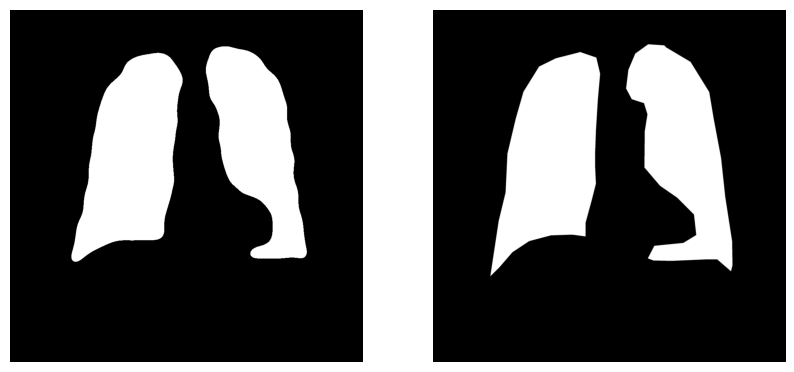

In [9]:
import cv2
import numpy as np
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage import morphology
import matplotlib.pyplot as plt

# Suavizar iluminación general
n = 280
Xe = cv2.morphologyEx(X3, cv2.MORPH_OPEN,
                      cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n)))

# Corregir iluminación restando el fondo
Xd = X3.astype(float) - Xe.astype(float)
Xd_uint8 = Xd.astype('uint8')

# Umbral para separar zonas claras
th = 35
D = Xd_uint8 > th

# Quitar regiones pequeñas aisladas
S = morphology.remove_small_objects(D, min_size=10000, connectivity=2)

# Quitar objetos tocando el borde
clean = clear_border(S)

# Cierre grande para unir pulmones
kernel = np.ones((30, 30), np.uint8)
lungs_uint8 = (clean.astype('uint8')) * 255
closing = cv2.morphologyEx(lungs_uint8, cv2.MORPH_CLOSE, kernel)

# Apertura suave para limpiar bordes finos
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
smooth = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel1)

# Cierre grande para redondear y estirar contornos
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (65, 65))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel2)

# Suavizado final del borde
smooth = cv2.GaussianBlur(smooth, (81, 81), 0)

# Re-umbralizar para recuperar máscara binaria
_, final_round_3 = cv2.threshold(smooth, 127, 255, cv2.THRESH_BINARY)

# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(final_round_3, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(M3 , cmap="gray")
plt.axis("off")
plt.show()

In [10]:
final_round_3 = (final_round_3 > 127).astype(float)
M3 = (M3 > 127).astype(float)

E3 = error_promedio(final_round_3, M3)
print("Error promedio =", E3)

Error promedio = 0.028697


# Segmentacion Imagen 4

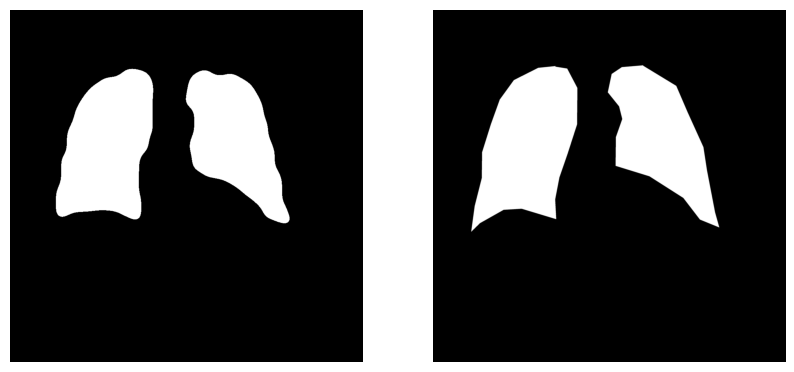

In [11]:
import cv2
import numpy as np
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage import morphology
import matplotlib.pyplot as plt

# Suavizar iluminación general
n = 280
Xe = cv2.morphologyEx(X4, cv2.MORPH_OPEN,
                      cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n)))
Xd = X4.astype(float) - Xe.astype(float)

# Ajustar rango y convertir
Xd_clipped = np.clip(Xd, 0, 255)
Xd_uint8 = Xd_clipped.astype('uint8')

# Umbral para seleccionar zonas claras
th = 40
D = Xd_uint8 > th

# Quitar regiones pequeñas
S = morphology.remove_small_objects(D, min_size=10000, connectivity=0)

# Quitar objetos tocando bordes
clean = clear_border(S)

# Cierre grande para unir regiones
kernel = np.ones((30, 30), np.uint8)
lungs_uint8 = (clean.astype('uint8')) * 255
closing = cv2.morphologyEx(lungs_uint8, cv2.MORPH_CLOSE, kernel)

# Apertura suave para limpiar bordes finos
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
smooth = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel1)

# Cierre grande para redondear y estirar contornos
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (65, 65))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel2)

# Corrección vertical
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel_vertical)

# Suavizado final del borde
smooth = cv2.GaussianBlur(smooth, (81, 81), 0)

# Re-umbralizar para recuperar máscara binaria
_, final_round_4 = cv2.threshold(smooth, 127, 255, cv2.THRESH_BINARY)

# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(final_round_4, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(M4 , cmap="gray")
plt.axis("off")
plt.show()

In [12]:
final_round_4 = (final_round_4 > 127).astype(float)
M4 = (M4 > 127).astype(float)

E4 = error_promedio(final_round_4, M4)
print("Error promedio =", E4)

Error promedio = 0.023966


# Segmentacion Imagen 5

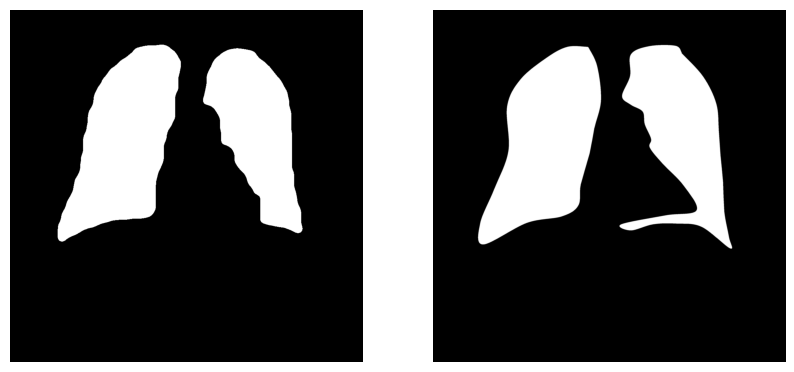

In [13]:
import cv2
import numpy as np
from skimage.segmentation import clear_border
from skimage.measure import label, regionprops
from skimage import morphology
import matplotlib.pyplot as plt

# Suavizar iluminación general
n = 280
Xe = cv2.morphologyEx(X5, cv2.MORPH_OPEN,
                      cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n)))
Xd = X5.astype(float) - Xe.astype(float)

# Ajustar rango y convertir
Xd_clipped = np.clip(Xd, 0, 255)
Xd_uint8 = Xd_clipped.astype('uint8')

# Umbral para seleccionar zonas claras
th = 30
D = Xd_uint8 > th

# Quitar regiones pequeñas
S = morphology.remove_small_objects(D, min_size=10000, connectivity=2)

# Quitar objetos tocando bordes
clean = clear_border(S)

# Cierre grande para unir regiones
kernel = np.ones((30, 30), np.uint8)
lungs_uint8 = (clean.astype('uint8')) * 255
closing = cv2.morphologyEx(lungs_uint8, cv2.MORPH_CLOSE, kernel)

# Apertura suave para limpiar bordes
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
smooth = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel1)

# Cierre grande para redondear contornos
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (65, 65))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel2)

# Corrección vertical
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
smooth = cv2.morphologyEx(smooth, cv2.MORPH_CLOSE, kernel_vertical)

# Suavizado final del borde
smooth = cv2.GaussianBlur(smooth, (27, 27), 0)

# Re-umbralizar máscara final
_, final_round_5 = cv2.threshold(smooth, 127, 255, cv2.THRESH_BINARY)

# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(final_round_5, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(M5 , cmap="gray")
plt.axis("off")
plt.show()

In [14]:
final_round_5 = (final_round_5 > 127).astype(float)
M5 = (M5 > 127).astype(float)

E5 = error_promedio(final_round_5, M5)
print("Error promedio =", E5)

Error promedio = 0.029238


In [15]:
# Promedio de errores de Segmentación 1
err5_1 = (E1 + E2 + E3 + E4 + E5) / 5
print("Promedio Segmentación 1 =", err5_1)

Promedio Segmentación 1 = 0.032177199999999996


# 2) "Segmentacion2": Usando otros algoritmos no vistos en clase.

El método no visto en clase que utilicé fue el algoritmo Random Walker. Primero aproveché una característica importante de las radiografías: los pulmones son mucho más claros que la mayor parte del cuerpo y de los huesos. Con esa idea generé tres zonas usando umbrales simples: una zona clara (que corresponde al fondo y aire), una zona oscura (huesos y partes muy densas) y una zona intermedia (donde normalmente están los pulmones). Estas tres zonas sirven como “marcadores”, es decir, indicaciones iniciales de qué regiones deberían pertenecer a cada categoría.

Random Walker no segmenta automáticamente los pulmones ni descubre bordes nuevos. Lo que hace es tomar los marcadores y “propagarlos” suavemente por la imagen, asignando cada píxel al marcador más adecuado según la intensidad y la continuidad de la región. En otras palabras, el algoritmo solo completa, suaviza y separa las zonas que yo definí previamente con los umbrales.

Después, seleccioné únicamente la región correspondiente a la zona intermedia (los pulmones) y eliminé las partes que tocaban las orillas exteriores del cuerpo para evitar confusiones con áreas claras que no pertenecen a los pulmones e hice el posprocesamiento para tratar de recuperar las partes de los pulmones que se perdieron por los huesos sobre estas.

De igual forma utilice otras correcciones morfologicas y metodos nuevos que no habiamos visto dentro de los codigos vistos en clases, como realizar operaciones morfologicas por zonas o usar disk para el procesado post segmentacion para ver si habia una mejora con respecto a las operaciones morfologicas que habiamos visto.

# Segmentacion Imagen 1

/usr/local/lib/python3.12/dist-packages/skimage/segmentation/random_walker_segmentation.py:545: UserWarning: Random walker only segments unlabeled areas, where labels == 0. No zero valued areas in labels were found. Returning provided labels.
  (labels, nlabels, mask, inds_isolated_seeds, isolated_values) = _preprocess(labels)


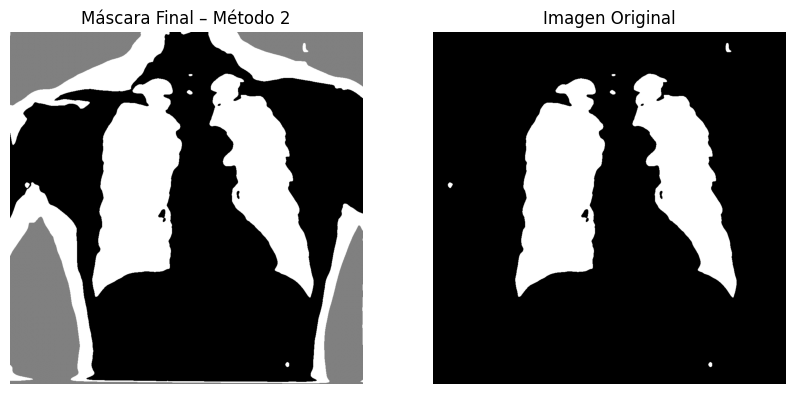

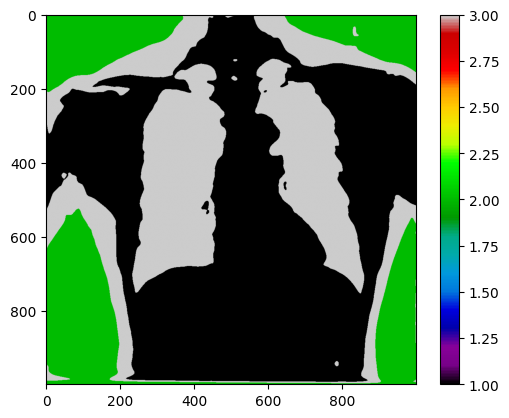

In [4]:
import cv2
import numpy as np
from skimage.segmentation import random_walker, clear_border
from skimage.filters import threshold_otsu, gaussian
from skimage import morphology
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt

# Convertir a float — necesario porque las operaciones de suavizado y normalización
# funcionan mejor en rango continuo y evita saturación.
X = X1.astype(float)

# Suavizado fuerte — elimina ruido fino y atenúa costillas y estructuras óseas delgadas.
# Esto ayuda a que el umbral y el Random Walker se guíen más por el pulmón completo
# y menos por los bordes de las costillas.
Xs = gaussian(X, sigma=4)

# Normalizar — llevar todo a [0, 1], facilita definir marcadores con factores del umbral.
Xn = (Xs - Xs.min()) / (Xs.max() - Xs.min())

# Umbral global — Otsu entrega un valor que separa general "oscuro" de "claro".
# A partir de este umbral crearemos marcadores adaptados para fondo, hueso y pulmón.
th = threshold_otsu(Xn)

# Inicialización de marcadores para Random Walker.
# RW necesita saber qué regiones son seguro fondo, seguro hueso y región intermedia (posible pulmón).
M = np.zeros_like(Xn, dtype=np.int32)

# Fondo claro (aire externo): intensidad mayor — muy por encima del umbral.
# Esto evita que RW confunda aire con pulmón.
M[Xn > th * 1.2] = 2

# Regiones muy oscuras (huesos densos, columna, mediastino).
# Las costillas generan sombras delgadas que se marcan aquí como hueso, no pulmón.
M[Xn < th * 0.51] = 1

# Zona intermedia = pulmón real.
# Aquí es donde RW debe expandirse para seguir la cavidad pulmonar completa.
M[(Xn >= th * 0.51) & (Xn <= th * 1.2)] = 3

# Random Walker — realiza segmentación suave propagando las etiquetas.
# El objetivo es que el pulmón (región 3) se expanda por dentro del tórax
# sin meterse en huesos ni fondo claro.
L = random_walker(Xn, M, beta=300, mode='bf')

# Extraer solo la clase "pulmón"
D = (L == 3)

# Eliminar regiones tocando los bordes de la imagen.
# Esto quita partes del fondo que se parecían a pulmón debido a sombras externas,
# especialmente cerca de los bordes del tórax.
D = clear_border(D)


# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(M, cmap="gray")
plt.title("Máscara Final – Método 2")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(D, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")
plt.show()

plt.imshow(L, cmap='nipy_spectral')
plt.colorbar()
plt.show()

Aqui podemos las 3 regiones que mencione en un inicio

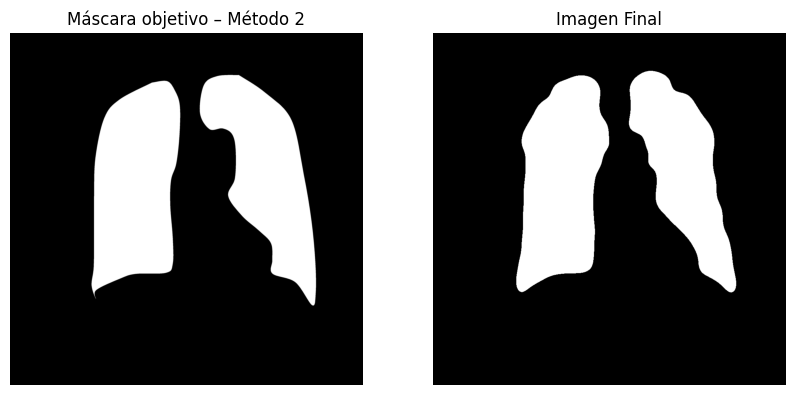

In [5]:
# PROCESADO POST-SEGMENTACIÓN DE PULMONES
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects
from skimage import morphology, filters

D = D.astype(np.uint8) * 255

# Apertura morfológica pequeña — elimina restos de costillas marcadas erróneamente como pulmón.
# También suaviza pequeños artefactos dentro del pulmón.
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
mask_clean = cv2.morphologyEx(D, cv2.MORPH_OPEN, kernel_small)

# Cierre vertical — corrige cortes en los bordes laterales del pulmón
# que aparecen porque las costillas oscurecen zonas y RW las separa como si fueran huecos.
# Este kernel alto une las partes laterales del contorno pulmonar.
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
mask_rect = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_vertical)

# Convertir a booleano para operaciones de skimage
mask_rect_bool = mask_rect.astype(bool)

# Eliminar pequeños objetos residuales (ruidos, estructuras muy pequeñas
# que no son parte del pulmón pero quedaron segmentadas).
mask_clean = remove_small_objects(mask_rect_bool, min_size=1500)

# Dilatación superior — compensa que la clavícula tapa la parte alta del pulmón
# y hace que la segmentación pierda esa zona.
# Dilatamos para recuperar esa parte perdida.
dil = morphology.dilation(mask_clean, morphology.disk(15))

# Crear máscara para permitir que la dilatación afecte solo la zona superior.
# Esto evita que el pulmón crezca hacia abajo y toque el diafragma.
h, w = mask_rect.shape
upper = np.zeros_like(mask_rect)
upper[:h // 3, :] = True  # Solo 1/3 superior

# Intersección — solo permitir llenar lo que se perdió por clavícula en parte alta.
grow_up = dil & upper

# Unir recuperación superior con la máscara base
mask = mask_clean | grow_up

# Cierre — unifica bordes y rellena agujeros medianos, especialmente
# los causados por sombras de costillas dentro del pulmón.
mask_closed = morphology.closing(mask, morphology.disk(10))

# Suavizado gaussiano final — crea bordes suaves para una máscara más natural.
mask_blur = cv2.GaussianBlur(mask.astype(np.uint8), (95, 95), 0)

# Re-umbralizado — recupera una máscara binaria luego del suavizado
mask_final_1 = mask_blur > 0.35

# Visualización de resultados
plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(M1, cmap="gray")
plt.title("Máscara objetivo – Método 2")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_final_1, cmap="gray")
plt.title("Imagen Final")
plt.axis("off")

plt.show()


In [6]:
mask_final_1 = (mask_final_1 > 127).astype(float)
M1 = (M1 > 127).astype(float)

E1_2 = error_promedio(mask_final_1, M1)
print("Error promedio =", E1_2)

Error promedio = 0.22284


Para las demas imagenes ocupe un codigo casi igual con algunas mosificaciones en los parametros de los marcadores ya que algunas imagenes tenian zonas mas claras que otras de las imagenes.

# Segmentacion Imagen 2

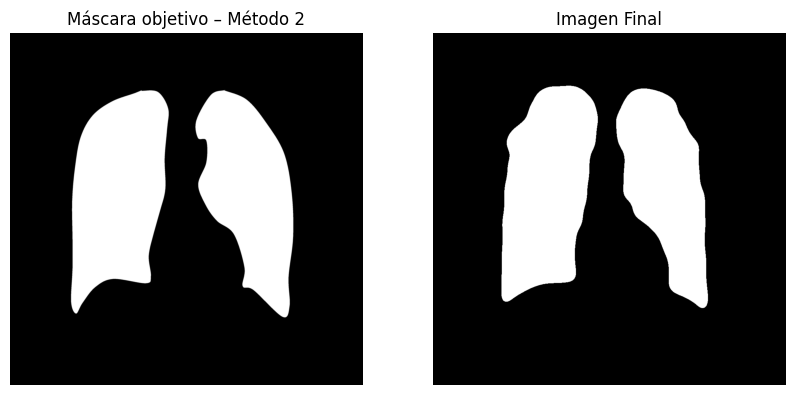

In [7]:
import cv2
import numpy as np
from skimage.segmentation import random_walker, clear_border
from skimage.filters import threshold_otsu, gaussian
from skimage import morphology
import matplotlib.pyplot as plt

X = X2.astype(float)
Xs = gaussian(X, sigma=4)

# NormalizaciOn
Xn = (Xs - Xs.min()) / (Xs.max() - Xs.min())

# Obtener un umbral
th = threshold_otsu(Xn)

# Construcción de marcadores
M = np.zeros_like(Xn, dtype=np.int32)
# Fondo claro (aire externo)
M[Xn > th*1.2] = 2
# Huesos oscuros (cuerpo y columna)
M[Xn < th * 0.51] = 1
# Región pulmonar (intermedio)
M[(Xn >= th * 0.51) & (Xn <= th * 1.2)] = 3


# Random Walker
L = random_walker(Xn, M, beta=300, mode='bf')

# Extraer máscara de pulmones
D = (L == 3)

# Eliminar marcadores tocando el borde externo (de zonas intermedias de color claro parecidas a los pulmones por alrededor del cuerpo)
D = clear_border(D)


# Procesado post segmentacion
D = D.astype(np.uint8) * 255

kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
mask_clean = cv2.morphologyEx(D, cv2.MORPH_OPEN, kernel_small)



# rectificar bordes laterales de los pulmones
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
mask_rect = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_vertical)


mask_rect_bool = mask_rect.astype(bool)
# Eliminar objetos pequeños (ruidos residuales)
mask_clean = remove_small_objects(mask_rect_bool, min_size=1500)


# DILATACIÓN SUPERIOR — Hacer crecer máscara hacia arriba (ya que es la parte donde mas se pierde pulmon por la superposicion de la clavicula)
dil = morphology.dilation(mask_clean, morphology.disk(15))

# CREAR MÁSCARA QUE SOLO PERMITE CRECIMIENTO ARRIBA
h, w = mask_rect.shape
upper = np.zeros_like(mask_rect)
upper[:h//3, :] = True

# INTERSECCIÓN
grow_up = dil & upper

# OMBINACIÓN FINAL — Unir expansión con máscara base
mask = mask_clean | grow_up

# cerrar huecos y unificar bordes
mask_closed = morphology.closing(mask, morphology.disk(10))

# Gaussian blur para borde suave en la transicion
mask_blur = cv2.GaussianBlur(mask, (95, 95), 0)

# Re-umbralizado para recuperar una máscara binaria suave
mask_final_2 = mask_blur > 0.35


# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(M2, cmap="gray")
plt.title("Máscara objetivo – Método 2")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_final_2, cmap="gray")
plt.title("Imagen Final")
plt.axis("off")
plt.show()


In [8]:
mask_final_2 = (mask_final_2 > 127).astype(float)
M2 = (M2 > 127).astype(float)

E2_2 = error_promedio(mask_final_2, M2)
print("Error promedio =", E2_2)

Error promedio = 0.238141


# Segmentacion Imagen 3

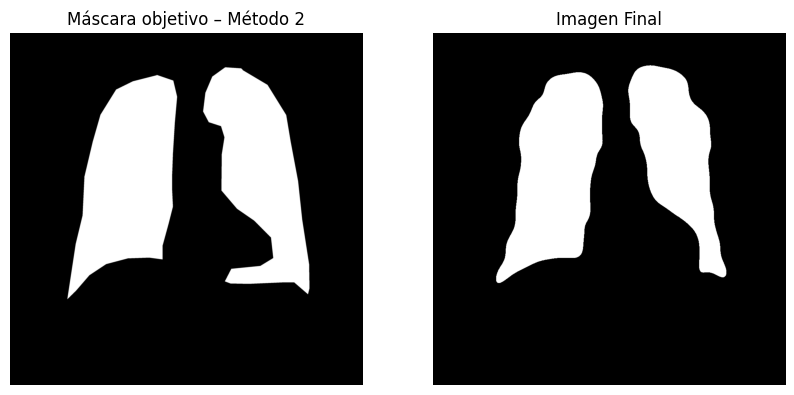

In [9]:
import cv2
import numpy as np
from skimage.segmentation import random_walker, clear_border
from skimage.filters import threshold_otsu, gaussian
from skimage import morphology
import matplotlib.pyplot as plt

X = X3.astype(float)
Xs = gaussian(X, sigma=4)

# NormalizaciOn
Xn = (Xs - Xs.min()) / (Xs.max() - Xs.min())

# Obtener un umbral
th = threshold_otsu(Xn)

# Construcción de marcadores
M = np.zeros_like(Xn, dtype=np.int32)
# Fondo claro (aire externo)
M[Xn > th*1.2] = 2
# Huesos oscuros (cuerpo y columna)
M[Xn < th * 0.6] = 1
# Región pulmonar (intermedio)
M[(Xn >= th * 0.6) & (Xn <= th * 1.2)] = 3


# Random Walker
L = random_walker(Xn, M, beta=300, mode='bf')

# Extraer máscara de pulmones
D = (L == 3)

# Eliminar marcadores tocando el borde externo (de zonas intermedias de color claro parecidas a los pulmones por alrededor del cuerpo)
D = clear_border(D)


# Procesado post segmentacion
D = D.astype(np.uint8) * 255

kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
mask_clean = cv2.morphologyEx(D, cv2.MORPH_OPEN, kernel_small)



# rectificar bordes laterales de los pulmones
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
mask_rect = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_vertical)


mask_rect_bool = mask_rect.astype(bool)
# Eliminar objetos pequeños (ruidos residuales)
mask_clean = remove_small_objects(mask_rect_bool, min_size=1500)


# DILATACIÓN SUPERIOR — Hacer crecer máscara hacia arriba (ya que es la parte donde mas se pierde pulmon por la superposicion de la clavicula)
dil = morphology.dilation(mask_clean, morphology.disk(15))

# CREAR MÁSCARA QUE SOLO PERMITE CRECIMIENTO ARRIBA
h, w = mask_rect.shape
upper = np.zeros_like(mask_rect)
upper[:h//3, :] = True

# INTERSECCIÓN
grow_up = dil & upper

# OMBINACIÓN FINAL — Unir expansión con máscara base
mask = mask_clean | grow_up

# cerrar huecos y unificar bordes
mask_closed = morphology.closing(mask, morphology.disk(10))

# Gaussian blur para borde suave en la transicion
mask_blur = cv2.GaussianBlur(mask, (95, 95), 0)

# Re-umbralizado para recuperar una máscara binaria suave
mask_final_3 = mask_blur > 0.35


# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(M3, cmap="gray")
plt.title("Máscara objetivo – Método 2")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_final_3, cmap="gray")
plt.title("Imagen Final")
plt.axis("off")
plt.show()


In [10]:
mask_final_3 = (mask_final_3 > 127).astype(float)
M3 = (M3 > 127).astype(float)

E3_2 = error_promedio(mask_final_3, M3)
print("Error promedio =", E3_2)

Error promedio = 0.230419


# Segmentacion Imagen 4

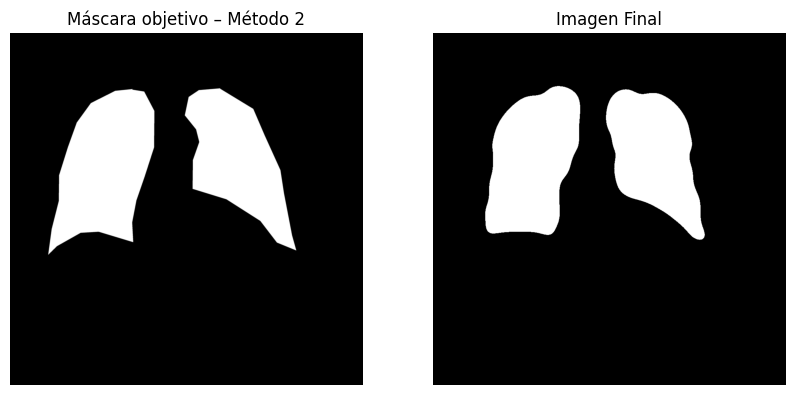

In [11]:
import cv2
import numpy as np
from skimage.segmentation import random_walker, clear_border
from skimage.filters import threshold_otsu, gaussian
from skimage import morphology
import matplotlib.pyplot as plt
from skimage.measure import label

X = X4.astype(float)
Xs = gaussian(X, sigma=10)

# NormalizaciOn
Xn = (Xs - Xs.min()) / (Xs.max() - Xs.min())

# Obtener un umbral
th = threshold_otsu(Xn)

# Construcción de marcadores
M = np.zeros_like(Xn, dtype=np.int32)
# Fondo claro (aire externo)
M[Xn > th*1.2] = 2
# Huesos oscuros (cuerpo y columna)
M[Xn < th * 0.6] = 1
# Región pulmonar (intermedio)
M[(Xn >= th * 0.6) & (Xn <= th * 1.2)] = 3


# Random Walker
L = random_walker(Xn, M, beta=300, mode='bf')

# Extraer máscara de pulmones
D = (L == 3)

# Eliminar marcadores tocando el borde externo (de zonas intermedias de color claro parecidas a los pulmones por alrededor del cuerpo)
D = clear_border(D)

#aqui tuve que hacer una modificacion para elegir las dos zonas segmentadas mas grandes ( ya que en esta imagen quedaban dos zonas extras bastante grandes y claras a parte de los pulmones)
# Partimos de D (máscara ya limpia con clear_border)
labels = label(D)
# Contar pixeles por componente (evitamos regionprops)
counts = np.bincount(labels.flat)
# counts[0] es fondo → lo ponemos en 0 para ignorarlo
counts[0] = 0
# Encontrar índices de las dos etiquetas con mayor área
# sin ordenar toda la lista
top2 = np.argpartition(counts, -2)[-2:]   # devuelve 2 índices mayores
# Crear máscara final conservando solo esas etiquetas
D2 = np.isin(labels, top2)

#tuve que rellenar tambien ya que quedaba un orificio:
D2_filled = morphology.remove_small_holes(D2, area_threshold=50000)


# Procesado post segmentacion
D2_filled = D2_filled.astype(np.uint8) * 255

kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
mask_clean = cv2.morphologyEx(D2_filled, cv2.MORPH_OPEN, kernel_small)



# rectificar bordes laterales de los pulmones
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
mask_rect = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_vertical)


mask_rect_bool = mask_rect.astype(bool)
# Eliminar objetos pequeños (ruidos residuales)
mask_clean = remove_small_objects(mask_rect_bool, min_size=1500)


# DILATACIÓN SUPERIOR — Hacer crecer máscara hacia arriba (ya que es la parte donde mas se pierde pulmon por la superposicion de la clavicula)
dil = morphology.dilation(mask_clean, morphology.disk(15))

# CREAR MÁSCARA QUE SOLO PERMITE CRECIMIENTO ARRIBA
h, w = mask_rect.shape
upper = np.zeros_like(mask_rect)
upper[:h//3, :] = True

# INTERSECCIÓN
grow_up = dil & upper

# OMBINACIÓN FINAL — Unir expansión con máscara base
mask = mask_clean | grow_up

# cerrar huecos y unificar bordes
mask_closed = morphology.closing(mask, morphology.disk(10))

# Gaussian blur para borde suave en la transicion
mask_blur = cv2.GaussianBlur(mask, (95, 95), 0)

# Re-umbralizado para recuperar una máscara binaria suave
mask_final_4 = mask_blur > 0.35


# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(M4, cmap="gray")
plt.title("Máscara objetivo – Método 2")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_final_4, cmap="gray")
plt.title("Imagen Final")
plt.axis("off")
plt.show()



In [12]:
mask_final_4 = (mask_final_4 > 127).astype(float)
M4 = (M4 > 127).astype(float)

E4_2 = error_promedio(mask_final_4, M4)
print("Error promedio =", E4_2)

Error promedio = 0.166503


# Segmentacion Imagen 5

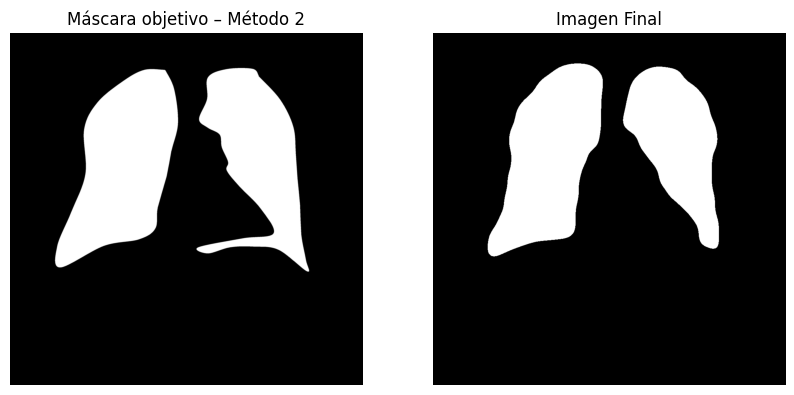

In [13]:
import cv2
import numpy as np
from skimage.segmentation import random_walker, clear_border
from skimage.filters import threshold_otsu, gaussian
from skimage import morphology
import matplotlib.pyplot as plt

X = X5.astype(float)
Xs = gaussian(X, sigma=4)

# NormalizaciOn
Xn = (Xs - Xs.min()) / (Xs.max() - Xs.min())

# Obtener un umbral
th = threshold_otsu(Xn)

# Construcción de marcadores
M = np.zeros_like(Xn, dtype=np.int32)
# Fondo claro (aire externo)
M[Xn > th*1.2] = 2
# Huesos oscuros (cuerpo y columna)
M[Xn < th * 0.48] = 1
# Región pulmonar (intermedio)
M[(Xn >= th * 0.48) & (Xn <= th * 1.2)] = 3


# Random Walker
L = random_walker(Xn, M, beta=300, mode='bf')

# Extraer máscara de pulmones
D = (L == 3)

# Eliminar marcadores tocando el borde externo (de zonas intermedias de color claro parecidas a los pulmones por alrededor del cuerpo)
D = clear_border(D)


# Procesado post segmentacion
D = D.astype(np.uint8) * 255

kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))
mask_clean = cv2.morphologyEx(D, cv2.MORPH_OPEN, kernel_small)



# rectificar bordes laterales de los pulmones
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 60))
mask_rect = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_vertical)


mask_rect_bool = mask_rect.astype(bool)
# Eliminar objetos pequeños (ruidos residuales)
mask_clean = remove_small_objects(mask_rect_bool, min_size=1500)


# DILATACIÓN SUPERIOR — Hacer crecer máscara hacia arriba (ya que es la parte donde mas se pierde pulmon por la superposicion de la clavicula)
dil = morphology.dilation(mask_clean, morphology.disk(15))

# CREAR MÁSCARA QUE SOLO PERMITE CRECIMIENTO ARRIBA
h, w = mask_rect.shape
upper = np.zeros_like(mask_rect)
upper[:h//3, :] = True

# INTERSECCIÓN
grow_up = dil & upper

# OMBINACIÓN FINAL — Unir expansión con máscara base
mask = mask_clean | grow_up

# cerrar huecos y unificar bordes
mask_closed = morphology.closing(mask, morphology.disk(10))

# Gaussian blur para borde suave en la transicion
mask_blur = cv2.GaussianBlur(mask, (95, 95), 0)

# Re-umbralizado para recuperar una máscara binaria suave
mask_final_5 = mask_blur > 0.35


# Visualización
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(M5, cmap="gray")
plt.title("Máscara objetivo – Método 2")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_final_5, cmap="gray")
plt.title("Imagen Final")
plt.axis("off")
plt.show()


In [14]:
mask_final_5 = (mask_final_5 > 127).astype(float)
M5 = (M5 > 127).astype(float)

E5_2 = error_promedio(mask_final_5, M5)
print("Error promedio =", E5_2)

Error promedio = 0.210666


In [15]:
# Promedio de errores de Segmentación 2
err5_2 = (E1_2 + E2_2 + E3_2 + E4_2 + E5_2) / 5
print("Promedio Segmentación 2 =", err5_2)

Promedio Segmentación 2 = 0.2137138
